#### Imports

In [5]:
import stim
import pymatching
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn.functional as F
from torch_geometric.data import Data, Batch
from torch_geometric.nn import MessagePassing
from torch_geometric.utils import add_self_loops, degree
from datetime import datetime
from pathlib import Path
from tqdm import tqdm
import os
import time
import json

# Import model classes and utilities from models.py
from models import (
    # STIM & MWPM utilities
    surface_code_circuit,
    count_logical_errors,
    ler_mwpm,
    plot_mwpm,
    # Surface Code Sampler
    SurfaceCodeSampler,
    # Sparse Graph
    SparseGraph,
    visualize_sparse_graph,
    # GCN Model
    GCNConv,
    GCNModel,
    GCN,
    # GAT Model
    GATModel,
    GAT,
)

KeyboardInterrupt: 

In [ ]:
# If CUDA is available, show more details
if torch.cuda.is_available():
    print(f"CUDA version: {torch.version.cuda}")
    print(f"Number of GPUs: {torch.cuda.device_count()}")
    print(f"GPU name: {torch.cuda.get_device_name(0)}")
    print(f"Current device: {torch.cuda.current_device()}")
else:
    print("PyTorch is using CPU only")

CUDA version: 13.0
Number of GPUs: 1
GPU name: NVIDIA GeForce RTX 5070 Ti
Current device: 0


In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

Using device: cuda


#### Definitions

In [ ]:
def test_gcn_accuracy(
    gcn: GCN,
    d: int,
    num_samples: int = 10000,
    p_values: list[float] = None,
    p_weights: list[float] = None,
    threshold: float = 0.5,
    compare_mwpm: bool = True,
    verbose: bool = True
) -> dict:
    """
    Test the accuracy of a trained GCN model.

    Args:
        gcn: Trained GCN model
        d: Code distance
        num_samples: Number of test samples to generate
        p_values: Error rates to test at (defaults to [0.005])
        p_weights: Weights for each error rate (defaults to uniform)
        threshold: Classification threshold (default 0.5)
        compare_mwpm: Whether to also compute MWPM accuracy for comparison
        verbose: Print results

    Returns:
        Dictionary containing accuracy metrics
    """
    from torch_geometric.data import Batch

    # Create sampler and graph_builder internally
    device = next(gcn.model.parameters()).device
    sampler = SurfaceCodeSampler(p=0.005, device=device)
    graph_builder = SparseGraph(k_neighbors=6, device=device)

    # Set model to eval mode
    gcn.model.eval()

    # Generate test data
    if p_values is None:
        p_values = [0.005]
    if p_weights is None:
        p_weights = [1.0 / len(p_values)] * len(p_values)

    test_detections, test_labels, p_indices = sampler.sample(
        d=d,
        num_samples=num_samples,
        p_values=p_values,
        p_weights=p_weights,
        return_p_labels=True
    )

    # Convert to graphs
    test_graphs = graph_builder.batch_to_pyg(test_detections, test_labels)

    # Run predictions in batches
    all_preds = []
    batch_size = 64

    with torch.no_grad():
        for i in range(0, len(test_graphs), batch_size):
            batch = Batch.from_data_list(test_graphs[i:i+batch_size])
            batch = batch.to(gcn.device)
            pred = gcn.model(batch)
            all_preds.append(pred.cpu())

    # Combine predictions
    predictions = torch.cat(all_preds, dim=0).squeeze()
    binary_preds = (predictions >= threshold).float()

    # Move labels to CPU for comparison
    labels_cpu = test_labels.cpu()

    # Calculate metrics
    correct = (binary_preds == labels_cpu).sum().item()
    accuracy = correct / num_samples

    # True positives, false positives, etc.
    tp = ((binary_preds == 1) & (labels_cpu == 1)).sum().item()
    fp = ((binary_preds == 1) & (labels_cpu == 0)).sum().item()
    fn = ((binary_preds == 0) & (labels_cpu == 1)).sum().item()
    tn = ((binary_preds == 0) & (labels_cpu == 0)).sum().item()

    precision = tp / (tp + fp) if (tp + fp) > 0 else 0.0
    recall = tp / (tp + fn) if (tp + fn) > 0 else 0.0
    f1 = 2 * precision * recall / (precision + recall) if (precision + recall) > 0 else 0.0

    results = {
        'num_samples': num_samples,
        'accuracy': accuracy,
        'precision': precision,
        'recall': recall,
        'f1': f1,
        'true_positives': tp,
        'false_positives': fp,
        'false_negatives': fn,
        'true_negatives': tn,
        'logical_error_rate_gcn': 1.0 - accuracy,
        'positive_rate': (tp + fn) / num_samples,  # actual rate of logical errors
    }

    # Per-error-rate breakdown with MWPM comparison
    per_p_accuracy = {}
    per_p_mwpm_accuracy = {}
    mwpm_errors_total = 0

    for i, p in enumerate(p_values):
        mask = (p_indices.cpu() == i)
        if mask.sum() > 0:
            # GCN accuracy for this p
            correct_p = (binary_preds[mask] == labels_cpu[mask]).sum().item()
            total_p = mask.sum().item()
            per_p_accuracy[p] = correct_p / total_p

            # MWPM accuracy for this p
            if compare_mwpm:
                circuit = sampler._get_circuit(d, p)
                mwpm_errors = count_logical_errors(circuit, total_p)
                per_p_mwpm_accuracy[p] = 1.0 - (mwpm_errors / total_p)
                mwpm_errors_total += mwpm_errors

    results['per_p_accuracy'] = per_p_accuracy
    results['per_p_mwpm_accuracy'] = per_p_mwpm_accuracy

    # Overall MWPM comparison
    if compare_mwpm:
        mwpm_accuracy = 1.0 - (mwpm_errors_total / num_samples)
        results['mwpm_accuracy'] = mwpm_accuracy
        results['logical_error_rate_mwpm'] = mwpm_errors_total / num_samples
        results['improvement_over_mwpm'] = accuracy - mwpm_accuracy

    if verbose:
        print("=" * 60)
        print("GCN Accuracy Test Results")
        print("=" * 60)
        print(f"Test samples: {num_samples}")
        print(f"Error rates tested: {p_values}")
        print("-" * 60)
        print(f"GCN Accuracy: {accuracy:.4f} ({correct}/{num_samples})")
        print(f"GCN Logical Error Rate: {results['logical_error_rate_gcn']:.4f}")
        print("-" * 60)
        print(f"Precision: {precision:.4f}")
        print(f"Recall: {recall:.4f}")
        print(f"F1 Score: {f1:.4f}")
        print("-" * 60)
        print(f"True Positives: {tp}")
        print(f"False Positives: {fp}")
        print(f"False Negatives: {fn}")
        print(f"True Negatives: {tn}")
        print("-" * 60)
        print("Per-error-rate accuracy:")
        for p in p_values:
            if p in per_p_accuracy:
                gcn_acc = per_p_accuracy[p]
                if compare_mwpm and p in per_p_mwpm_accuracy:
                    mwpm_acc = per_p_mwpm_accuracy[p]
                    diff = gcn_acc - mwpm_acc
                    print(f"  p={p}: GCN={gcn_acc:.4f}, MWPM={mwpm_acc:.4f} (diff={diff:+.4f})")
                else:
                    print(f"  p={p}: GCN={gcn_acc:.4f}")

        if compare_mwpm:
            print("-" * 60)
            print(f"Overall MWPM Accuracy: {mwpm_accuracy:.4f}")
            print(f"Overall MWPM Logical Error Rate: {results['logical_error_rate_mwpm']:.4f}")
            print(f"Overall GCN vs MWPM improvement: {results['improvement_over_mwpm']:+.4f}")
        print("=" * 60)

    return results

In [ ]:
def plot_ler_comparison(
    gcn: GCN,
    d: int,
    p_values: list[float] = None,
    samples_per_p: int = 2000,
    threshold: float = 0.5
):
    """
    Plot logical error rate comparison between GCN and MWPM across error rates.

    Args:
        gcn: Trained GCN model
        d: Code distance
        p_values: List of physical error rates to test
        samples_per_p: Number of samples per error rate
        threshold: Classification threshold
    """
    from torch_geometric.data import Batch

    # Create sampler and graph_builder internally
    device = next(gcn.model.parameters()).device
    sampler = SurfaceCodeSampler(p=0.005, device=device)
    graph_builder = SparseGraph(k_neighbors=6, device=device)

    if p_values is None:
        p_values = [0.001, 0.002, 0.003, 0.004, 0.005, 0.006, 0.007, 0.008]

    gcn.model.eval()

    gcn_lers = []
    mwpm_lers = []
    gcn_errs = []
    mwpm_errs = []

    for p in p_values:
        # Generate test data for this error rate
        detections, labels, _ = sampler.sample(
            d=d,
            num_samples=samples_per_p,
            p_values=[p],
            p_weights=[1.0],
            return_p_labels=True
        )

        # GCN prediction
        graphs = graph_builder.batch_to_pyg(detections, labels)
        all_preds = []
        batch_size = 64

        with torch.no_grad():
            for i in range(0, len(graphs), batch_size):
                batch = Batch.from_data_list(graphs[i:i+batch_size])
                batch = batch.to(gcn.device)
                pred = gcn.model(batch)
                all_preds.append(pred.cpu())

        predictions = torch.cat(all_preds, dim=0).squeeze()
        binary_preds = (predictions >= threshold).float()
        labels_cpu = labels.cpu()

        gcn_errors = (binary_preds != labels_cpu).sum().item()
        gcn_ler = gcn_errors / samples_per_p
        gcn_lers.append(gcn_ler)
        gcn_errs.append(np.sqrt(gcn_ler * (1 - gcn_ler) / samples_per_p))

        # MWPM prediction
        circuit = sampler._get_circuit(d, p)
        mwpm_errors = count_logical_errors(circuit, samples_per_p)
        mwpm_ler = mwpm_errors / samples_per_p
        mwpm_lers.append(mwpm_ler)
        mwpm_errs.append(np.sqrt(mwpm_ler * (1 - mwpm_ler) / samples_per_p))

        print(f"p={p:.4f}: GCN LER={gcn_ler:.4f}, MWPM LER={mwpm_ler:.4f}")

    # Plot
    fig, ax = plt.subplots(figsize=(10, 6))

    ax.errorbar(p_values, gcn_lers, yerr=gcn_errs, fmt='o-', label='GCN Decoder',
                capsize=3, markersize=8, linewidth=2)
    ax.errorbar(p_values, mwpm_lers, yerr=mwpm_errs, fmt='s--', label='MWPM Decoder',
                capsize=3, markersize=8, linewidth=2)

    ax.set_xlabel('Physical Error Rate (p)', fontsize=12)
    ax.set_ylabel('Logical Error Rate (LER)', fontsize=12)
    ax.set_title(f'GCN vs MWPM Decoder Performance (d={d})', fontsize=14)
    ax.legend(fontsize=11)
    ax.grid(True, alpha=0.3)
    ax.set_yscale('log')
    ax.set_xscale('log')

    plt.tight_layout()
    plt.show()

    return {'p_values': p_values, 'gcn_lers': gcn_lers, 'mwpm_lers': mwpm_lers}

#### Testing

In [ ]:
model = GCN().load("d3_baseline_2026-01-12_21-26-00.pt")

GCN initialized: GCN(nickname='gcn_model', in_channels=5, hidden_dim=128, num_layers=4)
Model loaded: GCN(nickname='d3_baseline', in_channels=5, hidden_dim=128, num_layers=4, loaded_from='d3_baseline_2026-01-12_21-26-00.pt')


In [ ]:
# Distance to test (should match training distance)
d = 3

# Call the test function (sampler and graph_builder are created internally)
results = test_gcn_accuracy(
    gcn=model,
    d=d,
    num_samples=10000,
    p_values=[0.001, 0.002, 0.003, 0.004, 0.005, 0.006, 0.007, 0.008, 0.009, 0.01],
    compare_mwpm=True
)

SurfaceCodeSampler initialized:
  Default error rate: 0.005
  Device: cuda:0
  Mode: Dynamic (supports any code distance)
SparseGraph initialized:
  K neighbors: 6
  Device: cuda:0
  Mode: Dynamic (supports any code distance)
GCN Accuracy Test Results
Test samples: 10000
Error rates tested: [0.001, 0.002, 0.003, 0.004, 0.005, 0.006, 0.007, 0.008, 0.009, 0.01]
------------------------------------------------------------
GCN Accuracy: 0.9581 (9581/10000)
GCN Logical Error Rate: 0.0419
------------------------------------------------------------
Precision: 0.8790
Recall: 0.7211
F1 Score: 0.7923
------------------------------------------------------------
True Positives: 799
False Positives: 110
False Negatives: 309
True Negatives: 8782
------------------------------------------------------------
Per-error-rate accuracy:
  p=0.001: GCN=1.0000, MWPM=1.0000 (diff=+0.0000)
  p=0.002: GCN=0.9950, MWPM=0.9930 (diff=+0.0020)
  p=0.003: GCN=0.9800, MWPM=0.9930 (diff=-0.0130)
  p=0.004: GCN=0.9830

SurfaceCodeSampler initialized:
  Default error rate: 0.005
  Device: cuda:0
  Mode: Dynamic (supports any code distance)
SparseGraph initialized:
  K neighbors: 6
  Device: cuda:0
  Mode: Dynamic (supports any code distance)
p=0.0010: GCN LER=0.0022, MWPM LER=0.0008
p=0.0030: GCN LER=0.0114, MWPM LER=0.0063
p=0.0050: GCN LER=0.0296, MWPM LER=0.0160
p=0.0070: GCN LER=0.0558, MWPM LER=0.0318
p=0.0100: GCN LER=0.1004, MWPM LER=0.0559
p=0.0150: GCN LER=0.1723, MWPM LER=0.1115
p=0.0200: GCN LER=0.2380, MWPM LER=0.1785


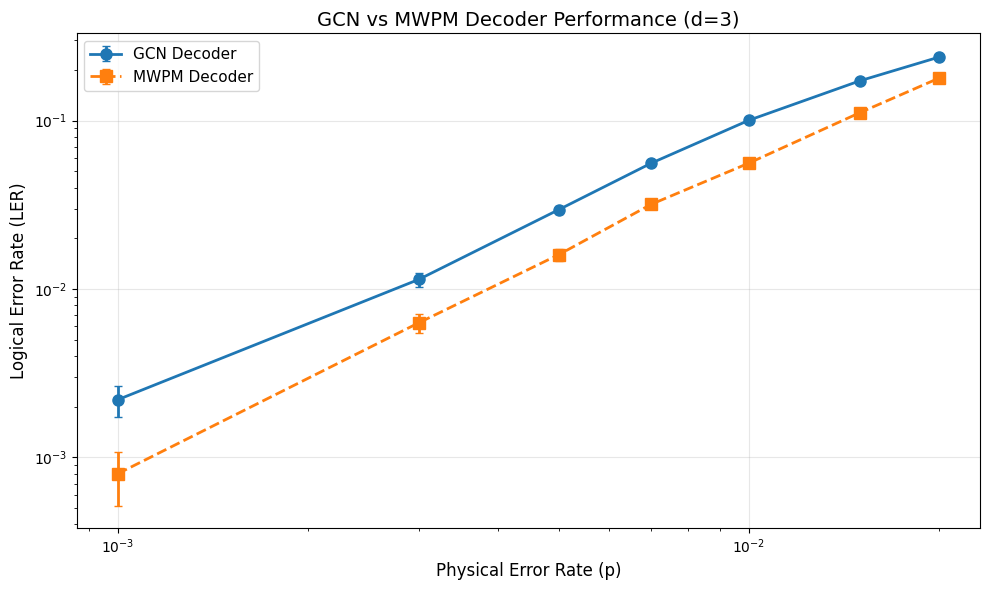

{'p_values': [0.001, 0.003, 0.005, 0.007, 0.01, 0.015, 0.02],
 'gcn_lers': [0.0022, 0.0114, 0.0296, 0.0558, 0.1004, 0.1723, 0.238],
 'mwpm_lers': [0.0008, 0.0063, 0.016, 0.0318, 0.0559, 0.1115, 0.1785]}

In [ ]:
# Test at more error rates with more samples for smoother curves
# (sampler and graph_builder are created internally)
plot_ler_comparison(
    gcn=model,
    d=3,
    p_values=[0.001, 0.003, 0.005, 0.007, 0.01, 0.015, 0.02],
    samples_per_p=10000  # more samples = less noisy plot
)

#### Inference Speed Benchmarking

In [ ]:
def benchmark_inference(
    model,
    model_type: str,  # "gcn" or "gat"
    d: int,
    num_samples: int = 10000,
    batch_size: int = 64,
    p: float = 0.005,
    num_warmup: int = 3,
    num_runs: int = 5,
    test_cpu: bool = True,
    test_cuda: bool = True,
    save_results: bool = True,
    verbose: bool = True
) -> dict:
    """
    Benchmark inference speed for a trained model and compare with MWPM.

    Args:
        model: Trained GCN or GAT model instance
        model_type: "gcn" or "gat"
        d: Code distance for test data generation
        num_samples: Number of fresh test samples to generate
        batch_size: Batch size for inference
        p: Physical error rate for test data
        num_warmup: Number of warmup batches to discard
        num_runs: Number of timed runs to average
        test_cpu: Whether to benchmark on CPU
        test_cuda: Whether to benchmark on CUDA (if available)
        save_results: Whether to save results to JSON
        verbose: Print progress and results

    Returns:
        Dictionary containing benchmark results
    """
    from torch_geometric.loader import DataLoader

    results = {
        'model_type': model_type,
        'model_nickname': model.nickname,
        'distance': d,
        'num_samples': num_samples,
        'batch_size': batch_size,
        'p': p,
        'num_runs': num_runs,
        'timestamp': datetime.now().isoformat(),
        'benchmarks': {}
    }

    # ==================== Generate Fresh Test Data ====================
    if verbose:
        print(f"{'='*70}")
        print(f"Inference Speed Benchmark")
        print(f"{'='*70}")
        print(f"Model: {model.nickname} ({model_type.upper()})")
        print(f"Distance: d={d}")
        print(f"Samples: {num_samples:,} | Batch size: {batch_size} | p={p}")
        print(f"{'='*70}")
        print(f"\nGenerating {num_samples:,} fresh test samples...")

    # Generate on CPU first
    cpu_device = torch.device("cpu")
    sampler = SurfaceCodeSampler(p=p, device=cpu_device)
    graph_builder = SparseGraph(k_neighbors=6, device=cpu_device)

    detections, labels = sampler.sample(d=d, num_samples=num_samples, p_values=[p], p_weights=[1.0])

    if verbose:
        print(f"Converting to graphs...")

    graphs = graph_builder.batch_to_pyg(detections, labels)

    if verbose:
        print(f"Generated {len(graphs):,} graphs")

    # ==================== MWPM Benchmark ====================
    if verbose:
        print(f"\n{'─'*70}")
        print(f"Benchmarking MWPM Decoder...")

    circuit = sampler._get_circuit(d, p)
    detector_error_model = circuit.detector_error_model(decompose_errors=True)
    matcher = pymatching.Matching.from_detector_error_model(detector_error_model)

    # Generate detection events for MWPM (need raw format, not graph)
    det_sampler = circuit.compile_detector_sampler()
    mwpm_detections, _ = det_sampler.sample(num_samples, separate_observables=True)

    # Warmup
    _ = matcher.decode_batch(mwpm_detections[:batch_size])

    # Timed runs
    mwpm_times = []
    samples_per_run = num_samples

    for run in range(num_runs):
        start = time.perf_counter()
        _ = matcher.decode_batch(mwpm_detections)
        elapsed = time.perf_counter() - start
        mwpm_times.append(elapsed)

    mwpm_avg_time = np.mean(mwpm_times)
    mwpm_std_time = np.std(mwpm_times)
    mwpm_throughput = num_samples / mwpm_avg_time
    mwpm_latency_ms = (mwpm_avg_time / num_samples) * 1000

    results['benchmarks']['mwpm'] = {
        'total_time_sec': mwpm_avg_time,
        'total_time_std': mwpm_std_time,
        'throughput_graphs_per_sec': mwpm_throughput,
        'latency_ms_per_graph': mwpm_latency_ms,
        'device': 'cpu'
    }

    if verbose:
        print(f"  MWPM: {mwpm_throughput:,.1f} graphs/sec | {mwpm_latency_ms:.4f} ms/graph")

    # ==================== Model Inference Benchmarks ====================
    devices_to_test = []
    if test_cpu:
        devices_to_test.append(('cpu', torch.device('cpu')))
    if test_cuda and torch.cuda.is_available():
        devices_to_test.append(('cuda', torch.device('cuda')))

    for device_name, device in devices_to_test:
        if verbose:
            print(f"\n{'─'*70}")
            print(f"Benchmarking {model_type.upper()} on {device_name.upper()}...")

        # Move model to device
        model.model.to(device)
        model.model.eval()
        model.device = device

        # Move graphs to device
        graphs_on_device = [g.to(device) for g in graphs]
        loader = DataLoader(graphs_on_device, batch_size=batch_size, shuffle=False)

        # Warmup runs
        if verbose:
            print(f"  Warming up ({num_warmup} batches)...")

        with torch.no_grad():
            warmup_count = 0
            for batch in loader:
                if warmup_count >= num_warmup:
                    break
                _ = model.model(batch)
                warmup_count += 1

        if device_name == 'cuda':
            torch.cuda.synchronize()

        # Timed runs
        run_times = []

        for run in range(num_runs):
            if device_name == 'cuda':
                torch.cuda.synchronize()

            start = time.perf_counter()

            with torch.no_grad():
                for batch in loader:
                    _ = model.model(batch)

            if device_name == 'cuda':
                torch.cuda.synchronize()

            elapsed = time.perf_counter() - start
            run_times.append(elapsed)

        avg_time = np.mean(run_times)
        std_time = np.std(run_times)
        throughput = num_samples / avg_time
        latency_ms = (avg_time / num_samples) * 1000

        results['benchmarks'][f'{model_type}_{device_name}'] = {
            'total_time_sec': avg_time,
            'total_time_std': std_time,
            'throughput_graphs_per_sec': throughput,
            'latency_ms_per_graph': latency_ms,
            'device': device_name
        }

        if verbose:
            print(f"  {model_type.upper()} ({device_name}): {throughput:,.1f} graphs/sec | {latency_ms:.4f} ms/graph")

    # ==================== Summary Table ====================
    if verbose:
        print(f"\n{'='*70}")
        print(f"SUMMARY: Inference Speed Comparison")
        print(f"{'='*70}")
        print(f"{'Decoder':<20} {'Device':<10} {'Throughput':<20} {'Latency':<15} {'vs MWPM':<12}")
        print(f"{'─'*70}")

        for key, bench in results['benchmarks'].items():
            decoder = key.split('_')[0].upper() if '_' in key else key.upper()
            dev = bench['device'].upper()
            tp = f"{bench['throughput_graphs_per_sec']:,.1f} graphs/sec"
            lat = f"{bench['latency_ms_per_graph']:.4f} ms"

            if key == 'mwpm':
                speedup = "baseline"
            else:
                speedup_val = mwpm_throughput / bench['throughput_graphs_per_sec']
                if speedup_val > 1:
                    speedup = f"{speedup_val:.2f}x slower"
                else:
                    speedup = f"{1/speedup_val:.2f}x faster"

            print(f"{decoder:<20} {dev:<10} {tp:<20} {lat:<15} {speedup:<12}")

        print(f"{'='*70}")
        print(f"\nReal-world deployment estimate (per graph):")

        for key, bench in results['benchmarks'].items():
            if key != 'mwpm':
                decoder = key.replace('_', ' ').upper()
                latency = bench['latency_ms_per_graph']
                print(f"  {decoder}: {latency:.4f} ms = {latency*1000:.2f} μs")

    # ==================== Save Results ====================
    if save_results:
        benchmarks_dir = Path("benchmarks")
        benchmarks_dir.mkdir(exist_ok=True)

        filename = f"benchmark_{model_type}_d{d}_{datetime.now().strftime('%Y-%m-%d_%H-%M-%S')}.json"
        filepath = benchmarks_dir / filename

        with open(filepath, 'w') as f:
            json.dump(results, f, indent=2)

        if verbose:
            print(f"\nResults saved to: {filepath}")

    return results

In [ ]:
def plot_benchmark_results(results: dict, save_path: str = None):
    """
    Visualize benchmark results as a bar chart.

    Args:
        results: Dictionary from benchmark_inference()
        save_path: Optional path to save the figure
    """
    benchmarks = results['benchmarks']

    # Prepare data
    labels = []
    throughputs = []
    colors = []

    color_map = {
        'mwpm': '#2ecc71',      # green
        'gcn_cpu': '#3498db',   # blue
        'gcn_cuda': '#9b59b6',  # purple
        'gat_cpu': '#e67e22',   # orange
        'gat_cuda': '#e74c3c',  # red
    }

    for key, bench in benchmarks.items():
        if key == 'mwpm':
            label = 'MWPM (CPU)'
        else:
            parts = key.split('_')
            label = f"{parts[0].upper()} ({parts[1].upper()})"

        labels.append(label)
        throughputs.append(bench['throughput_graphs_per_sec'])
        colors.append(color_map.get(key, '#95a5a6'))

    # Create figure
    fig, ax = plt.subplots(figsize=(10, 6))

    x = np.arange(len(labels))
    bars = ax.bar(x, throughputs, color=colors, edgecolor='black', linewidth=1.2)

    # Add value labels on bars
    for bar, tp in zip(bars, throughputs):
        height = bar.get_height()
        ax.annotate(f'{tp:,.0f}',
                    xy=(bar.get_x() + bar.get_width() / 2, height),
                    xytext=(0, 3),
                    textcoords="offset points",
                    ha='center', va='bottom', fontsize=10, fontweight='bold')

    ax.set_ylabel('Throughput (graphs/sec)', fontsize=12)
    ax.set_xlabel('Decoder', fontsize=12)
    ax.set_title(f"Inference Speed Comparison\n{results['model_nickname']} | d={results['distance']} | n={results['num_samples']:,}",
                 fontsize=14)
    ax.set_xticks(x)
    ax.set_xticklabels(labels, fontsize=11)
    ax.grid(axis='y', alpha=0.3)

    # Add latency as secondary info
    latency_text = "Latency per graph:\n"
    for key, bench in benchmarks.items():
        if key == 'mwpm':
            name = 'MWPM'
        else:
            parts = key.split('_')
            name = f"{parts[0].upper()} ({parts[1]})"
        latency_text += f"  {name}: {bench['latency_ms_per_graph']:.4f} ms\n"

    ax.text(0.98, 0.98, latency_text.strip(), transform=ax.transAxes, fontsize=9,
            verticalalignment='top', horizontalalignment='right',
            bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

    plt.tight_layout()

    if save_path:
        plt.savefig(save_path, dpi=150, bbox_inches='tight')
        print(f"Figure saved to: {save_path}")

    plt.show()

    return fig

##### Run Benchmark

In [ ]:
# =============================================================================
# SELECT YOUR MODEL AND DISTANCE HERE
# =============================================================================

# Model type: "gcn" or "gat"
MODEL_TYPE = "gat"

# Model filename (check models/gcn/ or models/gat/ for available models)
MODEL_FILE = "d3_baseline_2026-01-13_17-35-13.pt"

# Distance for test data (should match the model's training distance)
DISTANCE = 3

# =============================================================================
# Load the selected model
# =============================================================================

if MODEL_TYPE == "gcn":
    model = GCN(device=device).load(MODEL_FILE)
elif MODEL_TYPE == "gat":
    model = GAT(device=device).load(MODEL_FILE)
else:
    raise ValueError(f"Unknown model type: {MODEL_TYPE}")

NameError: name 'GAT' is not defined

In [ ]:
# Run the benchmark
results = benchmark_inference(
    model=model,
    model_type=MODEL_TYPE,
    d=DISTANCE,
    num_samples=10000,
    batch_size=64,
    p=0.005,
    num_warmup=3,
    num_runs=5,
    test_cpu=True,
    test_cuda=torch.cuda.is_available(),
    save_results=True,
    verbose=True
)

In [ ]:
# Visualize the results
plot_benchmark_results(results, save_path=f"benchmarks/benchmark_{MODEL_TYPE}_d{DISTANCE}.png")